#Carga de Datos

In [1]:
import pandas as pd
import numpy as np
from tabulate import tabulate
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os 

df_caracteristicas_equipos = pd.read_csv('../data/Caracteristicas_Equipos.csv')
df_caracteristicas_equipos
df_historicos_ordenes = pd.read_csv('../data/Historicos_Ordenes.csv')
df_historicos_ordenes
df_registros_condiciones = pd.read_csv('../data/Registros_Condiciones.csv')
df_registros_condiciones

,ID_Registro,ID_Equipo,Fecha,Temperatura_C,Vibracion_mm_s,Horas_Operativas
0,1,260,2020-01-01 00:00:00,101.43,1.22,71849.0
1,2,376,2020-01-01 01:00:00,118.51,2.97,49670.0
2,3,443,2020-01-01 02:00:00,76.04,2.93,33106.0
3,4,281,2020-01-01 03:00:00,97.09,3.25,31744.0
4,5,427,2020-01-01 04:00:00,139.42,4.22,78104.0
...,...,...,...,...,...,...
8995,8996,299,2021-01-09 19:00:00,51.08,2.32,97743.0
8996,8997,160,2021-01-09 20:00:00,122.18,2.65,84374.0
8997,8998,160,2021-01-09 21:00:00,119.70,2.98,16939.0
8998,8999,45,2021-01-09 22:00:00,57.77,3.39,86679.0


Revisión Nulos

In [3]:
df_caracteristicas_equipos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505 entries, 0 to 504
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID_Equipo                    505 non-null    int64  
 1   Tipo_Equipo                  505 non-null    object 
 2   Fabricante                   505 non-null    object 
 3   Modelo                       505 non-null    object 
 4   Potencia_kW                  505 non-null    float64
 5   Horas_Recomendadas_Revision  505 non-null    int64  
dtypes: float64(1), int64(2), object(3)
memory usage: 23.8+ KB


In [4]:
df_historicos_ordenes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10020 entries, 0 to 10019
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID_Orden             10020 non-null  int64  
 1   ID_Equipo            10020 non-null  int64  
 2   Fecha                10020 non-null  object 
 3   Tipo_Mantenimiento   10020 non-null  object 
 4   Costo_Mantenimiento  9971 non-null   float64
 5   Duracion_Horas       10020 non-null  int64  
 6   Ubicacion            10020 non-null  object 
dtypes: float64(1), int64(3), object(3)
memory usage: 548.1+ KB


In [5]:
df_historicos_ordenes.head()

,ID_Orden,ID_Equipo,Fecha,Tipo_Mantenimiento,Costo_Mantenimiento,Duracion_Horas,Ubicacion
0,1,36,2020-01-01 00:00:00,Preventivo,6754.12,3,Planta Norte
1,2,244,2020-01-01 01:00:00,Preventivo,4274.63,35,Planta Norte
2,3,297,2020-01-01 02:00:00,Preventivo,5752.00,25,Planta Norte
3,4,431,2020-01-01 03:00:00,Correctivo,5690.14,8,Planta Sur
4,5,403,2020-01-01 04:00:00,Correctivo,7048.79,28,Planta Norte


In [6]:
df_historicos_ordenes.tail()

,ID_Orden,ID_Equipo,Fecha,Tipo_Mantenimiento,Costo_Mantenimiento,Duracion_Horas,Ubicacion
10015,16,203,2020-01-01 15:00:00,Preventivo,320.94,46,Planta Norte
10016,17,386,2020-01-01 16:00:00,Preventivo,2806.72,20,Planta Oeste
10017,18,122,2020-01-01 17:00:00,Preventivo,8919.97,14,Planta Norte
10018,19,33,2020-01-01 18:00:00,Preventivo,6522.17,24,Planta Sur
10019,20,390,2020-01-01 19:00:00,Correctivo,1416.80,37,Planta Sur


In [7]:
df_historicos_ordenes.isna().sum()

ID_Orden                0
ID_Equipo               0
Fecha                   0
Tipo_Mantenimiento      0
Costo_Mantenimiento    49
Duracion_Horas          0
Ubicacion               0
dtype: int64

In [8]:
del_df_historicos_ordenes = df_historicos_ordenes.dropna()
del_df_historicos_ordenes

,ID_Orden,ID_Equipo,Fecha,Tipo_Mantenimiento,Costo_Mantenimiento,Duracion_Horas,Ubicacion
0,1,36,2020-01-01 00:00:00,Preventivo,6754.12,3,Planta Norte
1,2,244,2020-01-01 01:00:00,Preventivo,4274.63,35,Planta Norte
2,3,297,2020-01-01 02:00:00,Preventivo,5752.00,25,Planta Norte
3,4,431,2020-01-01 03:00:00,Correctivo,5690.14,8,Planta Sur
4,5,403,2020-01-01 04:00:00,Correctivo,7048.79,28,Planta Norte
...,...,...,...,...,...,...,...
10015,16,203,2020-01-01 15:00:00,Preventivo,320.94,46,Planta Norte
10016,17,386,2020-01-01 16:00:00,Preventivo,2806.72,20,Planta Oeste
10017,18,122,2020-01-01 17:00:00,Preventivo,8919.97,14,Planta Norte
10018,19,33,2020-01-01 18:00:00,Preventivo,6522.17,24,Planta Sur


In [9]:
del_df_historicos_ordenes.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9971 entries, 0 to 10019
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID_Orden             9971 non-null   int64  
 1   ID_Equipo            9971 non-null   int64  
 2   Fecha                9971 non-null   object 
 3   Tipo_Mantenimiento   9971 non-null   object 
 4   Costo_Mantenimiento  9971 non-null   float64
 5   Duracion_Horas       9971 non-null   int64  
 6   Ubicacion            9971 non-null   object 
dtypes: float64(1), int64(3), object(3)
memory usage: 623.2+ KB


In [10]:
df_registros_condiciones.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID_Registro       9000 non-null   int64  
 1   ID_Equipo         9000 non-null   int64  
 2   Fecha             9000 non-null   object 
 3   Temperatura_C     9000 non-null   float64
 4   Vibracion_mm_s    9000 non-null   float64
 5   Horas_Operativas  8960 non-null   float64
dtypes: float64(3), int64(2), object(1)
memory usage: 422.0+ KB


In [11]:
df_registros_condiciones.head()

,ID_Registro,ID_Equipo,Fecha,Temperatura_C,Vibracion_mm_s,Horas_Operativas
0,1,260,2020-01-01 00:00:00,101.43,1.22,71849.0
1,2,376,2020-01-01 01:00:00,118.51,2.97,49670.0
2,3,443,2020-01-01 02:00:00,76.04,2.93,33106.0
3,4,281,2020-01-01 03:00:00,97.09,3.25,31744.0
4,5,427,2020-01-01 04:00:00,139.42,4.22,78104.0


In [12]:
df_registros_condiciones.tail()

,ID_Registro,ID_Equipo,Fecha,Temperatura_C,Vibracion_mm_s,Horas_Operativas
8995,8996,299,2021-01-09 19:00:00,51.08,2.32,97743.0
8996,8997,160,2021-01-09 20:00:00,122.18,2.65,84374.0
8997,8998,160,2021-01-09 21:00:00,119.70,2.98,16939.0
8998,8999,45,2021-01-09 22:00:00,57.77,3.39,86679.0
8999,9000,61,2021-01-09 23:00:00,130.10,4.06,46702.0


In [13]:
df_registros_condiciones.isna().sum()

ID_Registro          0
ID_Equipo            0
Fecha                0
Temperatura_C        0
Vibracion_mm_s       0
Horas_Operativas    40
dtype: int64

In [14]:
del_df_registros_condiciones = df_registros_condiciones.dropna()
del_df_registros_condiciones

,ID_Registro,ID_Equipo,Fecha,Temperatura_C,Vibracion_mm_s,Horas_Operativas
0,1,260,2020-01-01 00:00:00,101.43,1.22,71849.0
1,2,376,2020-01-01 01:00:00,118.51,2.97,49670.0
2,3,443,2020-01-01 02:00:00,76.04,2.93,33106.0
3,4,281,2020-01-01 03:00:00,97.09,3.25,31744.0
4,5,427,2020-01-01 04:00:00,139.42,4.22,78104.0
...,...,...,...,...,...,...
8995,8996,299,2021-01-09 19:00:00,51.08,2.32,97743.0
8996,8997,160,2021-01-09 20:00:00,122.18,2.65,84374.0
8997,8998,160,2021-01-09 21:00:00,119.70,2.98,16939.0
8998,8999,45,2021-01-09 22:00:00,57.77,3.39,86679.0


In [15]:
del_df_registros_condiciones.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8960 entries, 0 to 8999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID_Registro       8960 non-null   int64  
 1   ID_Equipo         8960 non-null   int64  
 2   Fecha             8960 non-null   object 
 3   Temperatura_C     8960 non-null   float64
 4   Vibracion_mm_s    8960 non-null   float64
 5   Horas_Operativas  8960 non-null   float64
dtypes: float64(3), int64(2), object(1)
memory usage: 490.0+ KB


###### Duplicados

In [16]:
df_caracteristicas_equipos.duplicated().sum()

5

In [17]:
del_df_caracteristicas_equipos = df_caracteristicas_equipos.drop_duplicates()
del_df_caracteristicas_equipos

,ID_Equipo,Tipo_Equipo,Fabricante,Modelo,Potencia_kW,Horas_Recomendadas_Revision
0,1,Compresor,Siemens,Z300,3429.0,7725
1,2,Transformador,Siemens,Y200,75.0,7390
2,3,Compresor,ABB,Z300,4526.0,5238
3,4,Compresor,GE,X100,3981.0,8933
4,5,Motor,Siemens,Y200,377.0,5978
...,...,...,...,...,...,...
495,496,Transformador,Schneider,Z300,544.0,3331
496,497,Compresor,GE,M400,3296.0,8256
497,498,Generador,Siemens,X100,4231.0,9047
498,499,Motor,Siemens,Y200,3155.0,932


In [18]:
del_df_historicos_ordenes.duplicated().sum()

20

In [19]:
del_df_historicos_ordenes = del_df_historicos_ordenes.drop_duplicates()
del_df_historicos_ordenes

,ID_Orden,ID_Equipo,Fecha,Tipo_Mantenimiento,Costo_Mantenimiento,Duracion_Horas,Ubicacion
0,1,36,2020-01-01 00:00:00,Preventivo,6754.12,3,Planta Norte
1,2,244,2020-01-01 01:00:00,Preventivo,4274.63,35,Planta Norte
2,3,297,2020-01-01 02:00:00,Preventivo,5752.00,25,Planta Norte
3,4,431,2020-01-01 03:00:00,Correctivo,5690.14,8,Planta Sur
4,5,403,2020-01-01 04:00:00,Correctivo,7048.79,28,Planta Norte
...,...,...,...,...,...,...,...
9995,9996,127,2021-02-20 11:00:00,Correctivo,8326.79,16,Planta Este
9996,9997,237,2021-02-20 12:00:00,Preventivo,5563.86,32,Planta Este
9997,9998,120,2021-02-20 13:00:00,Preventivo,3972.80,41,Planta Sur
9998,9999,258,2021-02-20 14:00:00,Preventivo,9794.29,37,Planta Norte


In [20]:
del_df_registros_condiciones.duplicated().sum()

0

###### Inconsistencias

In [21]:
del_df_caracteristicas_equipos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID_Equipo                    500 non-null    int64  
 1   Tipo_Equipo                  500 non-null    object 
 2   Fabricante                   500 non-null    object 
 3   Modelo                       500 non-null    object 
 4   Potencia_kW                  500 non-null    float64
 5   Horas_Recomendadas_Revision  500 non-null    int64  
dtypes: float64(1), int64(2), object(3)
memory usage: 27.3+ KB


In [22]:
columns_to_convert = ['Tipo_Equipo','Fabricante','Modelo']

del_df_caracteristicas_equipos[columns_to_convert] = del_df_caracteristicas_equipos[columns_to_convert].astype('category')

/tmp/ipykernel_5439/3869328416.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  del_df_caracteristicas_equipos[columns_to_convert] = del_df_caracteristicas_equipos[columns_to_convert].astype('category')


In [23]:
del_df_caracteristicas_equipos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   ID_Equipo                    500 non-null    int64   
 1   Tipo_Equipo                  500 non-null    category
 2   Fabricante                   500 non-null    category
 3   Modelo                       500 non-null    category
 4   Potencia_kW                  500 non-null    float64 
 5   Horas_Recomendadas_Revision  500 non-null    int64   
dtypes: category(3), float64(1), int64(2)
memory usage: 17.7 KB


In [24]:
columns_to_convert = ['ID_Equipo','Potencia_kW','Horas_Recomendadas_Revision']

del_df_caracteristicas_equipos[columns_to_convert] = del_df_caracteristicas_equipos[columns_to_convert].apply(pd.to_numeric)


/tmp/ipykernel_5439/1357416204.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  del_df_caracteristicas_equipos[columns_to_convert] = del_df_caracteristicas_equipos[columns_to_convert].apply(pd.to_numeric)


In [25]:
del_df_caracteristicas_equipos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   ID_Equipo                    500 non-null    int64   
 1   Tipo_Equipo                  500 non-null    category
 2   Fabricante                   500 non-null    category
 3   Modelo                       500 non-null    category
 4   Potencia_kW                  500 non-null    float64 
 5   Horas_Recomendadas_Revision  500 non-null    int64   
dtypes: category(3), float64(1), int64(2)
memory usage: 17.7 KB


In [26]:
del_df_caracteristicas_equipos['Tipo_Equipo'].unique()

['Compresor', 'Transformador', 'Motor', 'Generador']
Categories (4, object): ['Compresor', 'Generador', 'Motor', 'Transformador']

In [27]:
del_df_caracteristicas_equipos['Fabricante'].unique()

['Siemens', 'ABB', 'GE', 'Schneider']
Categories (4, object): ['ABB', 'GE', 'Schneider', 'Siemens']

In [28]:
del_df_caracteristicas_equipos['Modelo'].unique()

['Z300', 'Y200', 'X100', 'M400']
Categories (4, object): ['M400', 'X100', 'Y200', 'Z300']

In [29]:
del_df_caracteristicas_equipos.head()

,ID_Equipo,Tipo_Equipo,Fabricante,Modelo,Potencia_kW,Horas_Recomendadas_Revision
0,1,Compresor,Siemens,Z300,3429.0,7725
1,2,Transformador,Siemens,Y200,75.0,7390
2,3,Compresor,ABB,Z300,4526.0,5238
3,4,Compresor,GE,X100,3981.0,8933
4,5,Motor,Siemens,Y200,377.0,5978


In [30]:
del_df_caracteristicas_equipos.isna().sum()

ID_Equipo                      0
Tipo_Equipo                    0
Fabricante                     0
Modelo                         0
Potencia_kW                    0
Horas_Recomendadas_Revision    0
dtype: int64

In [31]:
del_df_historicos_ordenes.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9951 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID_Orden             9951 non-null   int64  
 1   ID_Equipo            9951 non-null   int64  
 2   Fecha                9951 non-null   object 
 3   Tipo_Mantenimiento   9951 non-null   object 
 4   Costo_Mantenimiento  9951 non-null   float64
 5   Duracion_Horas       9951 non-null   int64  
 6   Ubicacion            9951 non-null   object 
dtypes: float64(1), int64(3), object(3)
memory usage: 621.9+ KB


In [32]:
del_df_historicos_ordenes['Fecha'] = pd.to_datetime(del_df_historicos_ordenes['Fecha'], errors='coerce')

/tmp/ipykernel_5439/4155844324.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  del_df_historicos_ordenes['Fecha'] = pd.to_datetime(del_df_historicos_ordenes['Fecha'], errors='coerce')


In [33]:
columns_to_convert = ['Tipo_Mantenimiento','Ubicacion']

del_df_historicos_ordenes[columns_to_convert] = del_df_historicos_ordenes[columns_to_convert].astype('category')

/tmp/ipykernel_5439/3719683965.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  del_df_historicos_ordenes[columns_to_convert] = del_df_historicos_ordenes[columns_to_convert].astype('category')


In [34]:
del_df_historicos_ordenes.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9951 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID_Orden             9951 non-null   int64         
 1   ID_Equipo            9951 non-null   int64         
 2   Fecha                9951 non-null   datetime64[ns]
 3   Tipo_Mantenimiento   9951 non-null   category      
 4   Costo_Mantenimiento  9951 non-null   float64       
 5   Duracion_Horas       9951 non-null   int64         
 6   Ubicacion            9951 non-null   category      
dtypes: category(2), datetime64[ns](1), float64(1), int64(3)
memory usage: 486.2 KB


In [35]:
columns_to_convert = ['ID_Orden','ID_Equipo','Costo_Mantenimiento', 'Duracion_Horas']

del_df_historicos_ordenes[columns_to_convert] = del_df_historicos_ordenes[columns_to_convert].apply(pd.to_numeric)

/tmp/ipykernel_5439/3969514718.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  del_df_historicos_ordenes[columns_to_convert] = del_df_historicos_ordenes[columns_to_convert].apply(pd.to_numeric)


In [36]:
del_df_historicos_ordenes.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9951 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID_Orden             9951 non-null   int64         
 1   ID_Equipo            9951 non-null   int64         
 2   Fecha                9951 non-null   datetime64[ns]
 3   Tipo_Mantenimiento   9951 non-null   category      
 4   Costo_Mantenimiento  9951 non-null   float64       
 5   Duracion_Horas       9951 non-null   int64         
 6   Ubicacion            9951 non-null   category      
dtypes: category(2), datetime64[ns](1), float64(1), int64(3)
memory usage: 486.2 KB


In [37]:
del_df_historicos_ordenes['Tipo_Mantenimiento'].unique()

['Preventivo', 'Correctivo']
Categories (2, object): ['Correctivo', 'Preventivo']

In [38]:
del_df_historicos_ordenes['Ubicacion'].unique()

['Planta Norte', 'Planta Sur', 'Planta Este', 'Planta Oeste']
Categories (4, object): ['Planta Este', 'Planta Norte', 'Planta Oeste', 'Planta Sur']

In [39]:
del_df_historicos_ordenes.head()

,ID_Orden,ID_Equipo,Fecha,Tipo_Mantenimiento,Costo_Mantenimiento,Duracion_Horas,Ubicacion
0,1,36,2020-01-01 00:00:00,Preventivo,6754.12,3,Planta Norte
1,2,244,2020-01-01 01:00:00,Preventivo,4274.63,35,Planta Norte
2,3,297,2020-01-01 02:00:00,Preventivo,5752.00,25,Planta Norte
3,4,431,2020-01-01 03:00:00,Correctivo,5690.14,8,Planta Sur
4,5,403,2020-01-01 04:00:00,Correctivo,7048.79,28,Planta Norte


In [40]:
del_df_registros_condiciones.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8960 entries, 0 to 8999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID_Registro       8960 non-null   int64  
 1   ID_Equipo         8960 non-null   int64  
 2   Fecha             8960 non-null   object 
 3   Temperatura_C     8960 non-null   float64
 4   Vibracion_mm_s    8960 non-null   float64
 5   Horas_Operativas  8960 non-null   float64
dtypes: float64(3), int64(2), object(1)
memory usage: 490.0+ KB


In [41]:
del_df_registros_condiciones['Fecha'] = pd.to_datetime(del_df_registros_condiciones['Fecha'], errors='coerce')

/tmp/ipykernel_5439/619741651.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  del_df_registros_condiciones['Fecha'] = pd.to_datetime(del_df_registros_condiciones['Fecha'], errors='coerce')


In [42]:
del_df_registros_condiciones.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8960 entries, 0 to 8999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   ID_Registro       8960 non-null   int64         
 1   ID_Equipo         8960 non-null   int64         
 2   Fecha             8960 non-null   datetime64[ns]
 3   Temperatura_C     8960 non-null   float64       
 4   Vibracion_mm_s    8960 non-null   float64       
 5   Horas_Operativas  8960 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(2)
memory usage: 490.0 KB


In [43]:
columns_to_convert = ['ID_Registro','ID_Equipo','Temperatura_C', 'Vibracion_mm_s','Horas_Operativas']

del_df_registros_condiciones[columns_to_convert] = del_df_registros_condiciones[columns_to_convert].apply(pd.to_numeric)

/tmp/ipykernel_5439/2333560292.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  del_df_registros_condiciones[columns_to_convert] = del_df_registros_condiciones[columns_to_convert].apply(pd.to_numeric)


In [44]:
del_df_registros_condiciones.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8960 entries, 0 to 8999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   ID_Registro       8960 non-null   int64         
 1   ID_Equipo         8960 non-null   int64         
 2   Fecha             8960 non-null   datetime64[ns]
 3   Temperatura_C     8960 non-null   float64       
 4   Vibracion_mm_s    8960 non-null   float64       
 5   Horas_Operativas  8960 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(2)
memory usage: 490.0 KB


In [45]:
del_df_registros_condiciones.head()

,ID_Registro,ID_Equipo,Fecha,Temperatura_C,Vibracion_mm_s,Horas_Operativas
0,1,260,2020-01-01 00:00:00,101.43,1.22,71849.0
1,2,376,2020-01-01 01:00:00,118.51,2.97,49670.0
2,3,443,2020-01-01 02:00:00,76.04,2.93,33106.0
3,4,281,2020-01-01 03:00:00,97.09,3.25,31744.0
4,5,427,2020-01-01 04:00:00,139.42,4.22,78104.0


###### Agregar nuevas columnas relevantes

###### Frecuencia de Mantenimiento

In [46]:
del_df_historicos_ordenes.sample(10)

,ID_Orden,ID_Equipo,Fecha,Tipo_Mantenimiento,Costo_Mantenimiento,Duracion_Horas,Ubicacion
7118,7119,156,2020-10-23 14:00:00,Correctivo,7130.56,32,Planta Norte
1619,1620,427,2020-03-08 11:00:00,Correctivo,8490.89,27,Planta Norte
5566,5567,222,2020-08-19 22:00:00,Preventivo,3750.20,36,Planta Este
6273,6274,196,2020-09-18 09:00:00,Preventivo,179.41,24,Planta Este
7047,7048,26,2020-10-20 15:00:00,Correctivo,5770.47,45,Planta Este
829,830,487,2020-02-04 13:00:00,Correctivo,2399.57,18,Planta Norte
2006,2007,164,2020-03-24 14:00:00,Correctivo,6484.97,18,Planta Sur
1179,1180,135,2020-02-19 03:00:00,Correctivo,3090.33,44,Planta Este
1826,1827,181,2020-03-17 02:00:00,Preventivo,9635.32,13,Planta Norte
1608,1609,235,2020-03-08 00:00:00,Correctivo,5596.60,2,Planta Oeste


In [47]:
frecuencia_mto = del_df_historicos_ordenes.groupby('ID_Equipo')['ID_Orden'].count().reset_index(name='Frecuencia_Mto')
frecuencia_mto

,ID_Equipo,Frecuencia_Mto
0,1,22
1,2,24
2,3,12
3,4,21
4,5,18
...,...,...
494,495,20
495,496,16
496,497,23
497,498,21


###### Vida útil

In [48]:
vida_util = del_df_registros_condiciones.groupby('ID_Equipo')['Horas_Operativas'].sum().reset_index(name='Vida_Util')
vida_util

,ID_Equipo,Vida_Util
0,1,870072.0
1,2,1222267.0
2,3,1150839.0
3,4,1214358.0
4,5,654608.0
...,...,...
494,495,713036.0
495,496,576452.0
496,497,383687.0
497,498,1077490.0


In [49]:
del_df_caracteristicas_equipos.head(10)

,ID_Equipo,Tipo_Equipo,Fabricante,Modelo,Potencia_kW,Horas_Recomendadas_Revision
0,1,Compresor,Siemens,Z300,3429.0,7725
1,2,Transformador,Siemens,Y200,75.0,7390
2,3,Compresor,ABB,Z300,4526.0,5238
3,4,Compresor,GE,X100,3981.0,8933
4,5,Motor,Siemens,Y200,377.0,5978
5,6,Transformador,GE,M400,423.0,5091
6,7,Transformador,Siemens,X100,2249.0,2896
7,8,Motor,ABB,X100,3607.0,3554
8,9,Generador,GE,Y200,3960.0,9489
9,10,Motor,Schneider,M400,465.0,9859


In [50]:
df_merged = pd.merge(frecuencia_mto, vida_util, on='ID_Equipo')
df_merged

new_del_df_caracteristicas_equipos = pd.merge(del_df_caracteristicas_equipos,df_merged, on='ID_Equipo')
new_del_df_caracteristicas_equipos

,ID_Equipo,Tipo_Equipo,Fabricante,Modelo,Potencia_kW,Horas_Recomendadas_Revision,Frecuencia_Mto,Vida_Util
0,1,Compresor,Siemens,Z300,3429.0,7725,22,870072.0
1,2,Transformador,Siemens,Y200,75.0,7390,24,1222267.0
2,3,Compresor,ABB,Z300,4526.0,5238,12,1150839.0
3,4,Compresor,GE,X100,3981.0,8933,21,1214358.0
4,5,Motor,Siemens,Y200,377.0,5978,18,654608.0
...,...,...,...,...,...,...,...,...
494,495,Motor,Schneider,Z300,3933.0,7775,20,713036.0
495,496,Transformador,Schneider,Z300,544.0,3331,16,576452.0
496,497,Compresor,GE,M400,3296.0,8256,23,383687.0
497,498,Generador,Siemens,X100,4231.0,9047,21,1077490.0


In [51]:
new_del_df_caracteristicas_equipos.to_csv('../output/Caracteristicas_Equipos_Agregado.csv', index=False)


####  Análisis Exploratorio de Datos con Python

 ###### Análisis Exploratorio de Datos con Python

In [52]:
!pip install ydata_profiling

In [53]:
from ydata_profiling import ProfileReport
 
profile1 = ProfileReport(new_del_df_caracteristicas_equipos, title = "Caracteristicas_Equipos profiling Report")

profile1.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [54]:
from ydata_profiling import ProfileReport
 
profile2 = ProfileReport(del_df_historicos_ordenes, title = "Historicos Ordenes profiling Report")

profile2.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [55]:
from ydata_profiling import ProfileReport
 
profile3 = ProfileReport(del_df_registros_condiciones, title = "Registros Condiciones profiling Report")

profile3.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

 ###### Análisis descriptivo de los datos:media, mediana y desviación estándar de las horas operativas, el costo de mantenimiento, y la frecuencia de fallos.

In [56]:
del_df_registros_condiciones.describe()




,ID_Registro,ID_Equipo,Fecha,Temperatura_C,Vibracion_mm_s,Horas_Operativas
count,8960.000000,8960.000000,8960,8960.000000,8960.000000,8960.000000
mean,4497.276004,248.850446,2020-07-06 08:16:33.616071424,102.644479,2.756233,50058.926674
min,1.000000,1.000000,2020-01-01 00:00:00,50.060000,0.100000,46.000000
25%,2245.750000,124.000000,2020-04-03 12:45:00,74.420000,1.320000,24937.500000
50%,4495.500000,247.000000,2020-07-06 06:30:00,99.580000,2.560000,50237.000000
75%,6749.250000,375.000000,2020-10-08 04:15:00,125.250000,3.830000,75240.250000
max,9000.000000,499.000000,2021-01-09 23:00:00,999.000000,95.285333,99991.000000
std,2599.366389,144.226211,NaN,59.442560,4.063816,28874.204890


In [57]:
print(del_df_registros_condiciones.median()['Horas_Operativas'])
print(del_df_registros_condiciones.mean()['Horas_Operativas'])
print(del_df_registros_condiciones.std()['Horas_Operativas'])

50237.0
50058.92667410714
28874.204890415047


In [58]:
q1 = np.percentile(del_df_registros_condiciones['Temperatura_C'], 25)
q3 = np.percentile(del_df_registros_condiciones['Temperatura_C'], 75)
iqr = q3 - q1
print('iqr:\n', iqr)

umbra_sup = q3+1.5*iqr
umbra_inf = q1-1.5*iqr

print('umbrales inf:\n', umbra_inf)
print('\numbrales sup:\n', umbra_sup)

iqr:
 50.83
umbrales inf:
 -1.8250000000000028

umbrales sup:
 201.495


In [59]:
rc_outliers = del_df_registros_condiciones['Temperatura_C'][((del_df_registros_condiciones['Temperatura_C'] < umbra_inf) | (del_df_registros_condiciones['Temperatura_C'] > umbra_sup))]
rc_outliers


1000    999.0
1232    999.0
1377    999.0
1446    999.0
1737    999.0
2009    999.0
2391    999.0
2534    999.0
3070    999.0
3346    999.0
3471    999.0
3654    999.0
3720    999.0
3991    999.0
4142    999.0
4375    999.0
4697    999.0
4747    999.0
4777    999.0
4911    999.0
5117    999.0
5196    999.0
5960    999.0
6457    999.0
6562    999.0
7131    999.0
7521    999.0
7752    999.0
8537    999.0
8744    999.0
Name: Temperatura_C, dtype: float64

In [60]:
rc_outliers.unique()

array([999.])

In [61]:
new_del_df_registros_condiciones = del_df_registros_condiciones[del_df_registros_condiciones['Temperatura_C'] < 999]
 
# ---- Mostrar resultado filtrado ----
new_del_df_registros_condiciones.head()



,ID_Registro,ID_Equipo,Fecha,Temperatura_C,Vibracion_mm_s,Horas_Operativas
0,1,260,2020-01-01 00:00:00,101.43,1.22,71849.0
1,2,376,2020-01-01 01:00:00,118.51,2.97,49670.0
2,3,443,2020-01-01 02:00:00,76.04,2.93,33106.0
3,4,281,2020-01-01 03:00:00,97.09,3.25,31744.0
4,5,427,2020-01-01 04:00:00,139.42,4.22,78104.0


In [62]:
del_df_historicos_ordenes.describe()

,ID_Orden,ID_Equipo,Fecha,Costo_Mantenimiento,Duracion_Horas
count,9951.000000,9951.000000,9951,9951.000000,9951.000000
mean,4999.629786,249.160386,2020-07-27 06:37:47.229424384,5255.840775,23.941312
min,1.000000,1.000000,2020-01-01 00:00:00,101.510000,1.000000
25%,2501.500000,125.000000,2020-04-14 04:30:00,2563.405000,12.000000
50%,4999.000000,248.000000,2020-07-27 06:00:00,5079.310000,24.000000
75%,7500.500000,373.000000,2020-11-08 11:30:00,7533.415000,36.000000
max,10000.000000,499.000000,2021-02-20 15:00:00,96354.868231,47.000000
std,2887.063516,143.878890,NaN,4711.601366,13.589686


In [63]:
print(del_df_historicos_ordenes['Costo_Mantenimiento'].median())
print(del_df_historicos_ordenes['Costo_Mantenimiento'].mean())
print(del_df_historicos_ordenes['Costo_Mantenimiento'].std())

5079.31
5255.840775394931
4711.6013661258485


In [64]:
del_df_historicos_ordenes.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9951 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID_Orden             9951 non-null   int64         
 1   ID_Equipo            9951 non-null   int64         
 2   Fecha                9951 non-null   datetime64[ns]
 3   Tipo_Mantenimiento   9951 non-null   category      
 4   Costo_Mantenimiento  9951 non-null   float64       
 5   Duracion_Horas       9951 non-null   int64         
 6   Ubicacion            9951 non-null   category      
dtypes: category(2), datetime64[ns](1), float64(1), int64(3)
memory usage: 744.2 KB


In [65]:
print(new_del_df_caracteristicas_equipos['Frecuencia_Mto'].median())
print(new_del_df_caracteristicas_equipos['Frecuencia_Mto'].mean())
print(new_del_df_caracteristicas_equipos['Frecuencia_Mto'].std())

20.0
19.94188376753507
4.405936719019584


###### Outliers

In [66]:
q1 = np.percentile(del_df_historicos_ordenes['Costo_Mantenimiento'], 25)
q3 = np.percentile(del_df_historicos_ordenes['Costo_Mantenimiento'], 75)
iqr = q3 - q1
print('iqr:\n', iqr)

umbra_sup = q3+1.5*iqr
umbra_inf = q1-1.5*iqr

print('umbrales inf:\n', umbra_inf)
print('\numbrales sup:\n', umbra_sup)

iqr:
 4970.01
umbrales inf:
 -4891.610000000001

umbrales sup:
 14988.43


In [67]:
am_outliers = del_df_historicos_ordenes['Costo_Mantenimiento'][((del_df_historicos_ordenes['Costo_Mantenimiento'] < umbra_inf) | (del_df_historicos_ordenes['Costo_Mantenimiento'] > umbra_sup))]
am_outliers

172     59674.687521
384     67082.733179
424     71857.600220
584     73048.320722
638     79265.076671
1875    86545.216355
2078    86861.031776
2519    79846.188496
2591    80366.318975
2722    94440.350492
2934    51070.866171
3094    86046.373247
3174    75166.642116
3454    61019.486848
3687    87878.453254
3990    66267.998930
4027    51161.548577
4069    73128.231581
4086    59145.163502
4290    54927.855673
5779    58343.942372
5780    87093.354710
7478    62654.835739
7579    56199.436825
7878    73698.187720
8329    77926.228411
8916    68894.685783
9008    78845.769408
9726    61961.982452
9986    96354.868231
Name: Costo_Mantenimiento, dtype: float64

In [68]:
"""z_scores = (del_df_registros_condiciones['Horas_Operativas']-np.mean(del_df_registros_condiciones['Horas_Operativas']))/np.std(del_df_registros_condiciones['Horas_Operativas'])
#print(z_scores)

umbral = 3
outliers = np.where(np.abs(z_scores) > umbral)

print(outliers)"""

q1 = np.percentile(del_df_registros_condiciones['Horas_Operativas'], 25)
q3 = np.percentile(del_df_registros_condiciones['Horas_Operativas'], 75)
iqr = q3 - q1
print('iqr:\n', iqr)

umbra_sup = q3+1.5*iqr
umbra_inf = q1-1.5*iqr

print('umbrales inf:\n', umbra_inf)
print('\numbrales sup:\n', umbra_sup)


iqr:
 50302.75
umbrales inf:
 -50516.625

umbrales sup:
 150694.375


In [69]:
am_outliers = del_df_registros_condiciones['Horas_Operativas'][((del_df_registros_condiciones['Horas_Operativas'] < umbra_inf) | (del_df_registros_condiciones['Horas_Operativas']> umbra_sup))]
am_outliers

Series([], Name: Horas_Operativas, dtype: float64)

###### Analizar la distribución de fallos y tipos de mantenimiento (correctivo/preventivo) de los equipos

In [70]:
del_df_historicos_ordenes.sample(10)

,ID_Orden,ID_Equipo,Fecha,Tipo_Mantenimiento,Costo_Mantenimiento,Duracion_Horas,Ubicacion
5585,5586,108,2020-08-20 17:00:00,Preventivo,1427.62,5,Planta Este
4997,4998,400,2020-07-27 05:00:00,Correctivo,2085.64,25,Planta Norte
7774,7775,224,2020-11-19 22:00:00,Preventivo,5454.32,38,Planta Oeste
1328,1329,102,2020-02-25 08:00:00,Preventivo,4486.04,4,Planta Este
6925,6926,362,2020-10-15 13:00:00,Correctivo,6226.05,4,Planta Norte
3235,3236,447,2020-05-14 19:00:00,Correctivo,8122.00,46,Planta Oeste
2797,2798,423,2020-04-26 13:00:00,Correctivo,7296.04,13,Planta Sur
4068,4069,310,2020-06-18 12:00:00,Correctivo,9267.00,25,Planta Este
1921,1922,168,2020-03-21 01:00:00,Correctivo,577.20,45,Planta Norte
5499,5500,65,2020-08-17 03:00:00,Preventivo,1987.06,32,Planta Norte


In [71]:
fallos = del_df_historicos_ordenes.sort_values('ID_Equipo').groupby(['ID_Equipo', 'Tipo_Mantenimiento'])['ID_Orden'].count().reset_index(name='Cantidad_Fallos')
fallos

/tmp/ipykernel_5439/2356731173.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fallos = del_df_historicos_ordenes.sort_values('ID_Equipo').groupby(['ID_Equipo', 'Tipo_Mantenimiento'])['ID_Orden'].count().reset_index(name='Cantidad_Fallos')


,ID_Equipo,Tipo_Mantenimiento,Cantidad_Fallos
0,1,Correctivo,8
1,1,Preventivo,14
2,2,Correctivo,14
3,2,Preventivo,10
4,3,Correctivo,7
...,...,...,...
993,497,Preventivo,10
994,498,Correctivo,10
995,498,Preventivo,11
996,499,Correctivo,6


In [72]:
!pip install matplotlib

/tmp/ipykernel_5439/3812936100.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fallos = del_df_historicos_ordenes.sort_values('ID_Equipo').groupby(['ID_Equipo', 'Tipo_Mantenimiento'])['ID_Orden'].count().reset_index(name='Cantidad_Fallos')


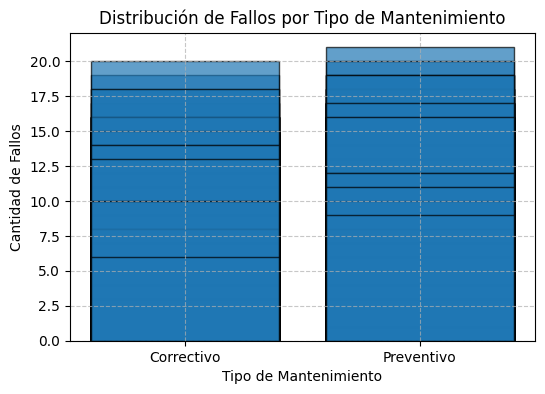

In [73]:
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns

fallos = del_df_historicos_ordenes.sort_values('ID_Equipo').groupby(['ID_Equipo', 'Tipo_Mantenimiento'])['ID_Orden'].count().reset_index(name='Cantidad_Fallos')
fallos

# Gráfico de barras para la cantidad de fallos por tipo de mantenimiento
plt.figure(figsize=(6,4))
plt.bar(fallos['Tipo_Mantenimiento'], fallos['Cantidad_Fallos'], alpha=0.7, edgecolor='black')
plt.title('Distribución de Fallos por Tipo de Mantenimiento')
plt.xlabel('Tipo de Mantenimiento')
plt.ylabel('Cantidad de Fallos')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


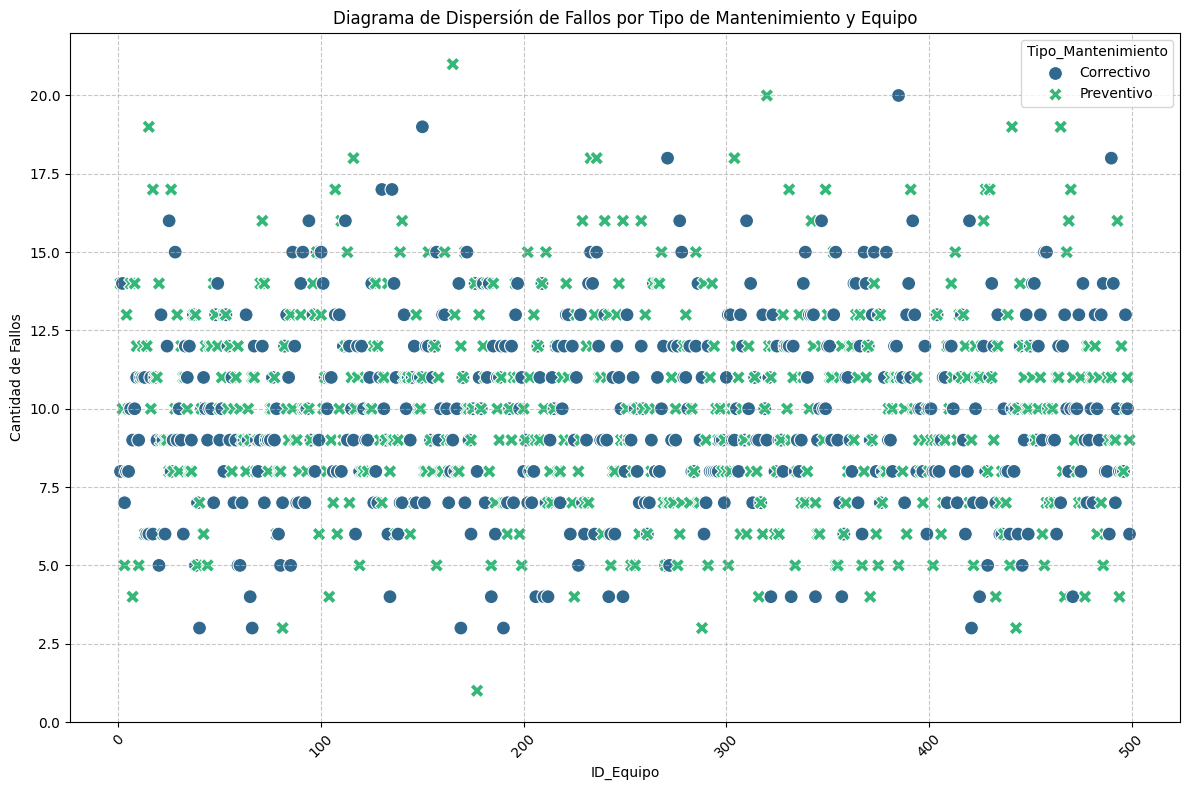

In [74]:
#Diagrama de dispersion

plt.figure(figsize=(12,8))
sns.scatterplot(data=fallos, x='ID_Equipo', y='Cantidad_Fallos', hue='Tipo_Mantenimiento', style='Tipo_Mantenimiento', s=100, palette='viridis')

plt.title('Diagrama de Dispersión de Fallos por Tipo de Mantenimiento y Equipo')
plt.xlabel('ID_Equipo')
plt.ylabel('Cantidad de Fallos')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

###### Establecer posibles correlaciones entre las variables, como la relación entre las condiciones operativas (temperatura, vibración) y las horas de operación.

In [75]:
new_del_df_registros_condiciones.info()
new_del_df_registros_condiciones.head()

<class 'pandas.core.frame.DataFrame'>
Index: 8930 entries, 0 to 8999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   ID_Registro       8930 non-null   int64         
 1   ID_Equipo         8930 non-null   int64         
 2   Fecha             8930 non-null   datetime64[ns]
 3   Temperatura_C     8930 non-null   float64       
 4   Vibracion_mm_s    8930 non-null   float64       
 5   Horas_Operativas  8930 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(2)
memory usage: 488.4 KB


,ID_Registro,ID_Equipo,Fecha,Temperatura_C,Vibracion_mm_s,Horas_Operativas
0,1,260,2020-01-01 00:00:00,101.43,1.22,71849.0
1,2,376,2020-01-01 01:00:00,118.51,2.97,49670.0
2,3,443,2020-01-01 02:00:00,76.04,2.93,33106.0
3,4,281,2020-01-01 03:00:00,97.09,3.25,31744.0
4,5,427,2020-01-01 04:00:00,139.42,4.22,78104.0


In [76]:
corr_registro_cond = new_del_df_registros_condiciones[['Horas_Operativas','Temperatura_C','Vibracion_mm_s']].corr()
corr_registro_cond

,Horas_Operativas,Temperatura_C,Vibracion_mm_s
Horas_Operativas,1.000000,0.002953,0.004119
Temperatura_C,0.002953,1.000000,0.001410
Vibracion_mm_s,0.004119,0.001410,1.000000


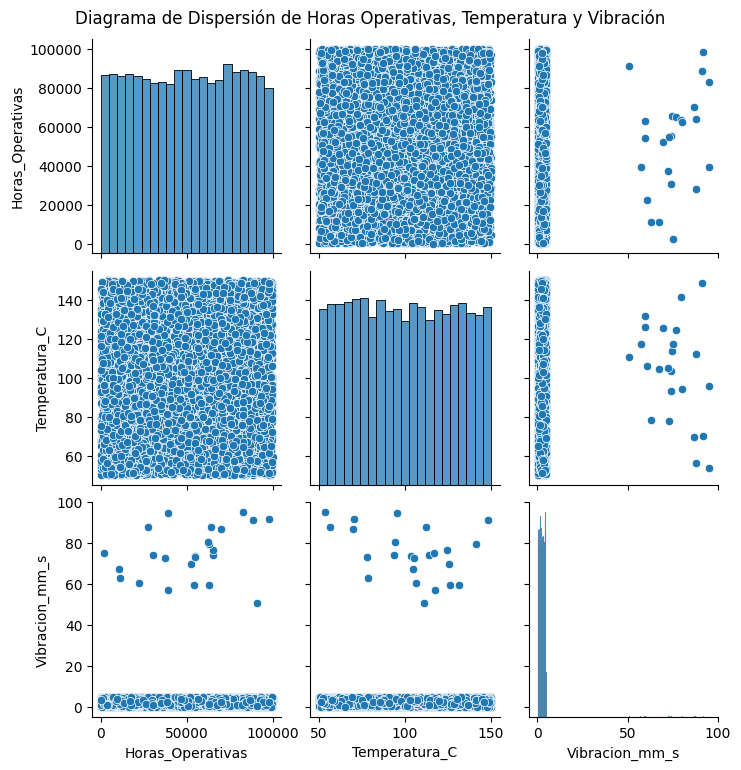

In [77]:
# Crear el diagrama de dispersión
sns.pairplot(new_del_df_registros_condiciones[['Horas_Operativas','Temperatura_C','Vibracion_mm_s']])
plt.suptitle('Diagrama de Dispersión de Horas Operativas, Temperatura y Vibración', y=1.02)
plt.show()

In [78]:
corr_registro_cond1 = new_del_df_registros_condiciones[['Horas_Operativas','Vibracion_mm_s']].corr()
corr_registro_cond1

,Horas_Operativas,Vibracion_mm_s
Horas_Operativas,1.000000,0.004119
Vibracion_mm_s,0.004119,1.000000


In [79]:

corr_registro_cond2 = new_del_df_registros_condiciones[['Horas_Operativas','Temperatura_C']].corr()
corr_registro_cond2

,Horas_Operativas,Temperatura_C
Horas_Operativas,1.000000,0.002953
Temperatura_C,0.002953,1.000000


#### Mezcla y Combinación de Datos

In [80]:
new_del_df_caracteristicas_equipos.info()
new_del_df_registros_condiciones.info()
del_df_historicos_ordenes.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 499 entries, 0 to 498
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   ID_Equipo                    499 non-null    int64   
 1   Tipo_Equipo                  499 non-null    category
 2   Fabricante                   499 non-null    category
 3   Modelo                       499 non-null    category
 4   Potencia_kW                  499 non-null    float64 
 5   Horas_Recomendadas_Revision  499 non-null    int64   
 6   Frecuencia_Mto               499 non-null    int64   
 7   Vida_Util                    499 non-null    float64 
dtypes: category(3), float64(2), int64(3)
memory usage: 21.7 KB
<class 'pandas.core.frame.DataFrame'>
Index: 8930 entries, 0 to 8999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   ID_Registro       8930 non-n

In [81]:
equipos_info = new_del_df_caracteristicas_equipos.merge(new_del_df_registros_condiciones, on='ID_Equipo', how='outer').merge(del_df_historicos_ordenes, on='ID_Equipo', how='outer')
equipos_info.info()
equipos_info.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178007 entries, 0 to 178006
Data columns (total 19 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   ID_Equipo                    178007 non-null  int64         
 1   Tipo_Equipo                  178007 non-null  category      
 2   Fabricante                   178007 non-null  category      
 3   Modelo                       178007 non-null  category      
 4   Potencia_kW                  178007 non-null  float64       
 5   Horas_Recomendadas_Revision  178007 non-null  int64         
 6   Frecuencia_Mto               178007 non-null  int64         
 7   Vida_Util                    178007 non-null  float64       
 8   ID_Registro                  178007 non-null  int64         
 9   Fecha_x                      178007 non-null  datetime64[ns]
 10  Temperatura_C                178007 non-null  float64       
 11  Vibracion_mm_s            

,ID_Equipo,Tipo_Equipo,Fabricante,Modelo,Potencia_kW,Horas_Recomendadas_Revision,Frecuencia_Mto,Vida_Util,ID_Registro,Fecha_x,Temperatura_C,Vibracion_mm_s,Horas_Operativas,ID_Orden,Fecha_y,Tipo_Mantenimiento,Costo_Mantenimiento,Duracion_Horas,Ubicacion
0,1,Compresor,Siemens,Z300,3429.0,7725,22,870072.0,28,2020-01-02 03:00:00,93.8,0.7,80054.0,799,2020-02-03 06:00:00,Preventivo,404.72,37,Planta Oeste
1,1,Compresor,Siemens,Z300,3429.0,7725,22,870072.0,28,2020-01-02 03:00:00,93.8,0.7,80054.0,837,2020-02-04 20:00:00,Correctivo,7465.08,39,Planta Este
2,1,Compresor,Siemens,Z300,3429.0,7725,22,870072.0,28,2020-01-02 03:00:00,93.8,0.7,80054.0,1344,2020-02-25 23:00:00,Correctivo,7577.35,40,Planta Norte
3,1,Compresor,Siemens,Z300,3429.0,7725,22,870072.0,28,2020-01-02 03:00:00,93.8,0.7,80054.0,1836,2020-03-17 11:00:00,Correctivo,5227.75,17,Planta Oeste
4,1,Compresor,Siemens,Z300,3429.0,7725,22,870072.0,28,2020-01-02 03:00:00,93.8,0.7,80054.0,2103,2020-03-28 14:00:00,Preventivo,6879.63,16,Planta Oeste


In [82]:

equipos_info.to_csv('../output/equipos_info.csv', index=False)




###### Nulos y Duplicados

In [83]:
equipos_info.isna().sum()

ID_Equipo                      0
Tipo_Equipo                    0
Fabricante                     0
Modelo                         0
Potencia_kW                    0
Horas_Recomendadas_Revision    0
Frecuencia_Mto                 0
Vida_Util                      0
ID_Registro                    0
Fecha_x                        0
Temperatura_C                  0
Vibracion_mm_s                 0
Horas_Operativas               0
ID_Orden                       0
Fecha_y                        0
Tipo_Mantenimiento             0
Costo_Mantenimiento            0
Duracion_Horas                 0
Ubicacion                      0
dtype: int64

In [84]:
equipos_info.duplicated().sum()

0

In [85]:
#Para verificar la alineación del dataframe

is_aligned_rows = equipos_info.index.is_monotonic_increasing
is_aligned_columns = equipos_info.columns.is_monotonic_increasing
has_unique_row_indices = equipos_info.index.is_unique
has_unique_column_indices = equipos_info.columns.is_unique

is_aligned = is_aligned_rows and is_aligned_columns and has_unique_row_indices and has_unique_column_indices

print("El DataFrame está alineado:", is_aligned)

El DataFrame está alineado: False


In [86]:
is_aligned_columns = equipos_info.columns.is_monotonic_increasing
print("Las columnas están alineadas:", is_aligned_columns)
#Devuelve False porque no están ordenadas alfabéticamente, por lo que el dataframe está correctamente alineado

Las columnas están alineadas: False


In [87]:
equipos_info.sample(5)

,ID_Equipo,Tipo_Equipo,Fabricante,Modelo,Potencia_kW,Horas_Recomendadas_Revision,Frecuencia_Mto,Vida_Util,ID_Registro,Fecha_x,Temperatura_C,Vibracion_mm_s,Horas_Operativas,ID_Orden,Fecha_y,Tipo_Mantenimiento,Costo_Mantenimiento,Duracion_Horas,Ubicacion
61086,166,Transformador,ABB,X100,275.0,7358,21,1042742.0,701,2020-01-30 04:00:00,139.87,0.53,43411.0,8501,2020-12-20 04:00:00,Correctivo,3138.71,3,Planta Sur
27529,77,Motor,ABB,X100,2395.0,2555,20,1134357.0,1970,2020-03-23 01:00:00,53.63,2.93,84020.0,2490,2020-04-13 17:00:00,Correctivo,687.88,2,Planta Este
104923,292,Transformador,Schneider,Z300,3230.0,8494,19,846884.0,501,2020-01-21 20:00:00,131.60,3.99,60980.0,3561,2020-05-28 08:00:00,Preventivo,7526.37,16,Planta Norte
140070,391,Motor,Schneider,Z300,396.0,5295,28,1059174.0,758,2020-02-01 13:00:00,108.39,1.58,10819.0,7561,2020-11-11 00:00:00,Preventivo,5982.24,5,Planta Este
27492,77,Motor,ABB,X100,2395.0,2555,20,1134357.0,831,2020-02-04 14:00:00,86.27,3.38,63551.0,3241,2020-05-15 00:00:00,Correctivo,2128.51,17,Planta Sur


###### Tiempo hasta fallo

In [88]:
equipos_correctivo = equipos_info[equipos_info['Tipo_Mantenimiento'] == 'Correctivo']
equipos_correctivo = equipos_correctivo.sort_values(by=['ID_Equipo', 'Fecha_y'])
equipos_correctivo['Diferencia_Fecha'] = equipos_correctivo.groupby('ID_Equipo')['Fecha_y'].diff()
tiempo_fallo = equipos_correctivo.groupby('ID_Equipo')['Diferencia_Fecha'].mean().reset_index()
tiempo_fallo.rename(columns={'Diferencia_Fecha': 'Media_Diferencia_Fecha'}, inplace=True)
tiempo_fallo.info()
tiempo_fallo.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 499 entries, 0 to 498
Data columns (total 2 columns):
 #   Column                  Non-Null Count  Dtype          
---  ------                  --------------  -----          
 0   ID_Equipo               499 non-null    int64          
 1   Media_Diferencia_Fecha  499 non-null    timedelta64[ns]
dtypes: int64(1), timedelta64[ns](1)
memory usage: 7.9 KB


,ID_Equipo,Media_Diferencia_Fecha
0,1,2 days 20:28:14.117647058
1,2,1 days 04:15:49.837133550
2,3,1 days 20:44:05.454545454
3,4,2 days 06:30:32.335329341
4,5,3 days 12:36:45.405405405


###### Prueba de correlación para ver en un solo equipo

Número de registros para el ID_Equipo 350: 204
Correlación entre las variables:
                  Horas_Operativas  Temperatura_C  Vibracion_mm_s
Horas_Operativas          1.000000       0.242938       -0.225977
Temperatura_C             0.242938       1.000000        0.184040
Vibracion_mm_s           -0.225977       0.184040        1.000000


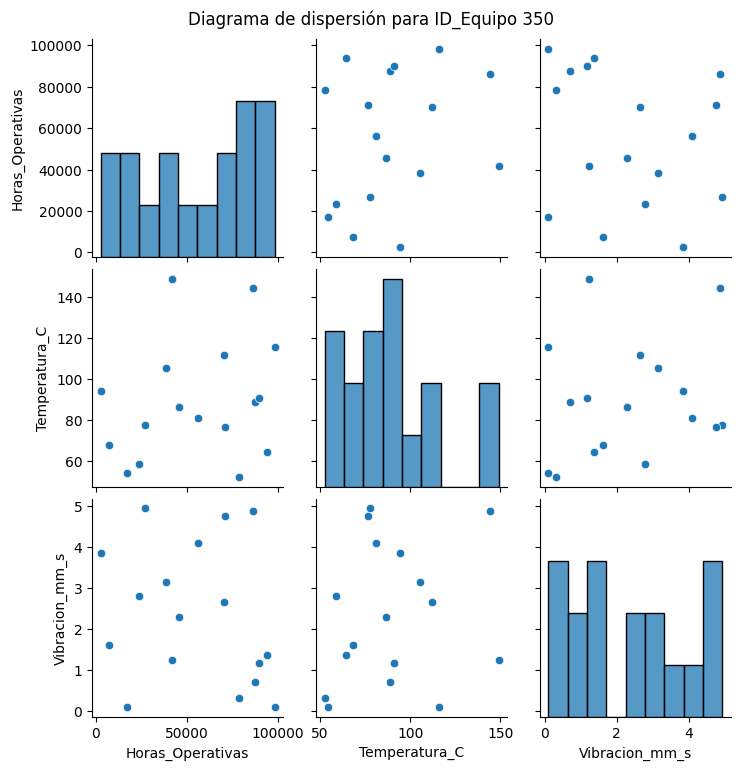

In [89]:
equipos_350 = equipos_correctivo[equipos_correctivo['ID_Equipo'] == 350]

# Contar el número de registros para el ID_Equipo 350
num_registros = equipos_350.shape[0]
print(f"Número de registros para el ID_Equipo 350: {num_registros}")

# Calcular la correlación entre las variables Horas_Operativas, Temperatura_C y Vibracion_mm_s
correlacion = equipos_350[['Horas_Operativas', 'Temperatura_C', 'Vibracion_mm_s']].corr()
print("Correlación entre las variables:")
print(correlacion)

# Generar un diagrama de dispersión para visualizar la distribución de las variables
sns.pairplot(equipos_350[['Horas_Operativas', 'Temperatura_C', 'Vibracion_mm_s']])
plt.suptitle('Diagrama de dispersión para ID_Equipo 350', y=1.02)
plt.show()

In [90]:
new_equipos_correctivo = pd.merge(equipos_correctivo,tiempo_fallo,on='ID_Equipo')
new_equipos_correctivo.sample(5)

,ID_Equipo,Tipo_Equipo,Fabricante,Modelo,Potencia_kW,Horas_Recomendadas_Revision,Frecuencia_Mto,Vida_Util,ID_Registro,Fecha_x,...,Vibracion_mm_s,Horas_Operativas,ID_Orden,Fecha_y,Tipo_Mantenimiento,Costo_Mantenimiento,Duracion_Horas,Ubicacion,Diferencia_Fecha,Media_Diferencia_Fecha
48083,273,Motor,Schneider,Y200,3607.0,6085,20,643988.0,4441,2020-07-04 00:00:00,...,1.36,31041.0,4410,2020-07-02 17:00:00,Correctivo,586.25,41,Planta Oeste,0 days 00:00:00,1 days 20:58:01.578947368
87983,497,Compresor,GE,M400,3296.0,8256,23,383687.0,4749,2020-07-16 20:00:00,...,4.62,62456.0,7933,2020-11-26 12:00:00,Correctivo,233.78,38,Planta Oeste,0 days 00:00:00,3 days 09:06:12.413793103
52229,296,Compresor,Schneider,X100,1192.0,6299,17,1115009.0,963,2020-02-10 02:00:00,...,4.63,73670.0,8370,2020-12-14 17:00:00,Correctivo,5659.62,44,Planta Este,0 days 00:00:00,2 days 19:31:53.286713286
38480,217,Compresor,ABB,Y200,4783.0,5133,20,827265.0,4180,2020-06-23 03:00:00,...,1.19,76661.0,5547,2020-08-19 02:00:00,Correctivo,4968.83,37,Planta Sur,0 days 00:00:00,1 days 14:22:28.017621145
74649,420,Generador,ABB,M400,1536.0,1999,23,624993.0,691,2020-01-29 18:00:00,...,1.11,51487.0,1297,2020-02-24 00:00:00,Correctivo,162.82,8,Planta Sur,4 days 17:00:00,1 days 10:41:24.132841328


In [91]:
new_equipos_correctivo = new_equipos_correctivo.drop(columns='Diferencia_Fecha')
new_equipos_correctivo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88365 entries, 0 to 88364
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype          
---  ------                       --------------  -----          
 0   ID_Equipo                    88365 non-null  int64          
 1   Tipo_Equipo                  88365 non-null  category       
 2   Fabricante                   88365 non-null  category       
 3   Modelo                       88365 non-null  category       
 4   Potencia_kW                  88365 non-null  float64        
 5   Horas_Recomendadas_Revision  88365 non-null  int64          
 6   Frecuencia_Mto               88365 non-null  int64          
 7   Vida_Util                    88365 non-null  float64        
 8   ID_Registro                  88365 non-null  int64          
 9   Fecha_x                      88365 non-null  datetime64[ns] 
 10  Temperatura_C                88365 non-null  float64        
 11  Vibracion_mm_s              

###### Relación entre condiciones operativas y fallos: ¿Cómo impactan la vibración o temperatura en la probabilidad de un fallo?

In [92]:
# Crear una columna que indique si el mantenimiento es correctivo
equipos_info['Fallo'] = (equipos_info['Tipo_Mantenimiento'] == 'Correctivo').astype(int)

# Contar el número de fallos y el número total de registros por ID_Equipo
fallos_por_equipo = equipos_info.groupby('ID_Equipo')['Fallo'].agg(['sum', 'count']).reset_index()

# Calcular la probabilidad de fallo
fallos_por_equipo['Probabilidad_Fallo'] = fallos_por_equipo['sum'] / fallos_por_equipo['count']

# Renombrar columnas para mayor claridad
fallos_por_equipo.columns = ['ID_Equipo', 'Numero_Fallos', 'Total_Registros', 'Probabilidad_Fallo']

# Mostrar el resultado
fallos_por_equipo.sample(10)

,ID_Equipo,Numero_Fallos,Total_Registros,Probabilidad_Fallo
376,377,200,375,0.533333
447,448,234,414,0.565217
423,424,231,462,0.500000
52,53,286,572,0.500000
120,121,250,450,0.555556
251,252,135,270,0.500000
58,59,100,340,0.294118
388,389,260,380,0.684211
98,99,207,345,0.600000
161,162,280,532,0.526316


In [93]:
# Unir la probabilidad de fallo con el DataFrame original
equipos_info = equipos_info.merge(fallos_por_equipo, on='ID_Equipo')

# Calcular la correlación entre Probabilidad_Fallo, Temperatura_C y Vibracion_mm_s
correlacion = equipos_info[['Probabilidad_Fallo', 'Temperatura_C', 'Vibracion_mm_s']].corr()

# Mostrar la tabla de correlación
correlacion

,Probabilidad_Fallo,Temperatura_C,Vibracion_mm_s
Probabilidad_Fallo,1.000000,0.000807,0.010236
Temperatura_C,0.000807,1.000000,0.002892
Vibracion_mm_s,0.010236,0.002892,1.000000


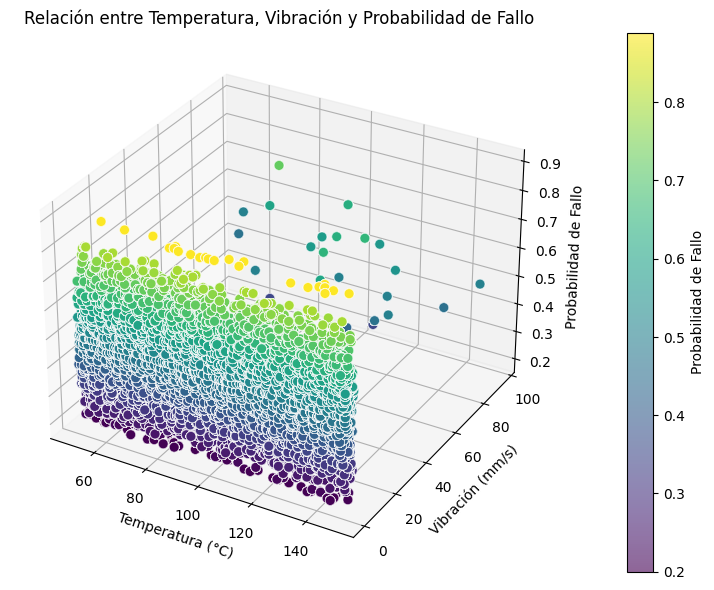

In [94]:
# Crear el gráfico de dispersión 3D
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot
scatter = ax.scatter(
    equipos_info['Temperatura_C'],
    equipos_info['Vibracion_mm_s'],
    equipos_info['Probabilidad_Fallo'],
    c=equipos_info['Probabilidad_Fallo'],
    cmap='viridis',
    s=50,
    alpha=0.6,
    edgecolors='w',
    linewidth=0.5
)

# Añadir colorbar
cbar = fig.colorbar(scatter, ax=ax, pad=0.1)
cbar.set_label('Probabilidad de Fallo')

# Etiquetas y título
ax.set_xlabel('Temperatura (°C)')
ax.set_ylabel('Vibración (mm/s)')
ax.set_zlabel('Probabilidad de Fallo')
ax.set_title('Relación entre Temperatura, Vibración y Probabilidad de Fallo')

# Mostrar el gráfico
plt.show()

 ## 4. Visualización de Datos

###### Crear gráficas de barras para mostrar la distribución del costo de mantenimiento por tipo de equipo.

In [ ]:
coste_mto = equipos_info.sort_values('Tipo_Equipo').groupby(['Tipo_Equipo', 'Costo_Mantenimiento']).count().reset_index()
coste_mto

# Gráfico de barras para la cantidad de fallos por tipo de mantenimiento
plt.figure(figsize=(6,4))
plt.bar(coste_mto['Tipo_Equipo'], coste_mto['Costo_Mantenimiento'], alpha=0.7, edgecolor='black')
plt.title('Distribución de Coste por Equipos')
plt.xlabel('Tipo_Equipo')
plt.ylabel('Coste_Mto')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


###### Crear diagramas de dispersión para visualizar la relación entre las condiciones operativas (por ejemplo, temperatura y vibración) y las horas de operación o fallos

In [ ]:
equipos_correctivo.sample(6)

In [ ]:
# Visualización de la relación entre temperatura y vibracion con horas operativas, por equipo

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    x=equipos_correctivo['Temperatura_C'],
    y=equipos_correctivo['Vibracion_mm_s'],
    c=equipos_correctivo['Horas_Operativas'],
    s=equipos_correctivo['ID_Equipo'],
    cmap='viridis',
    alpha=0.6,
    edgecolors='w',
    linewidth=0.5
)

# Añadir colorbar
plt.colorbar(scatter, label='Horas Operativas')

# Etiquetas y título
plt.xlabel('Temperatura (°C)')
plt.ylabel('Vibración (mm/s)')
plt.title('Diagrama de Dispersión de Equipos Correctivo')

# Mostrar el gráfico
plt.show()

In [ ]:
# Visualización de la relación entre temperatura y vibracion con tiempo hasta fallo, por equipo

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    x=new_equipos_correctivo['Temperatura_C'],
    y=new_equipos_correctivo['Vibracion_mm_s'],
    c=new_equipos_correctivo['Media_Diferencia_Fecha'],
    s=new_equipos_correctivo['ID_Equipo'],
    cmap='viridis',
    alpha=0.6,
    edgecolors='w',
    linewidth=0.5
)

# Añadir colorbar
plt.colorbar(scatter, label='Tiempo a Fallo en días')

# Etiquetas y título
plt.xlabel('Temperatura (°C)')
plt.ylabel('Vibración (mm/s)')
plt.title('Diagrama de Dispersión de Equipos Correctivo')

# Mostrar el gráfico
plt.show()

###### - Crear un diagrama de caja para identificar los outliers en las horas operativas o costos de mantenimiento

In [ ]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.boxplot(y=new_equipos_correctivo['Horas_Operativas'])
plt.title('Diagrama de Cajas de Horas Operativas')
plt.ylabel('Horas Operativas')

# Crear el diagrama de cajas para Costo_Mantenimiento
plt.subplot(1, 2, 2)
sns.boxplot(y=new_equipos_correctivo['Costo_Mantenimiento'])
plt.title('Diagrama de Cajas de Costo de Mantenimiento')
plt.ylabel('Costo de Mantenimiento')

# Mostrar los gráficos
plt.tight_layout()
plt.show()

###### Generar una visualización de la frecuencia de mantenimiento por tipo de equipo y la relación con el tipo de mantenimiento (correctivo/preventivo).

In [ ]:
ord_equipos_info = equipos_info.sort_values(by='Tipo_Equipo')
ver_equipos_info = ord_equipos_info.groupby(['Tipo_Equipo', 'Tipo_Mantenimiento'])['Frecuencia_Mto'].mean().reset_index()
ver_equipos_info.head()

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Tipo_Equipo', y='Frecuencia_Mto', hue='Tipo_Mantenimiento', data=ver_equipos_info)

# Añadir etiquetas y título
plt.xlabel('Tipo_Equipo')
plt.ylabel('Media de Freceuncia_Mto')
plt.title('Media de Frecuencia_Mto por Tipo de Mantenimiento y Tipo de Equipo')

# Mostrar el gráfico
plt.show()

 #### 5. Carga y Almacenamiento

###### Guardar el dataset final en:
###### 📂 CSV limpio para análisis exploratorio.
###### 🗄️ PostgreSQL para almacenamiento estructurado.
###### Opcional: Guardar en formato Parquet para optimizar rendimiento.

In [ ]:
!pip install pandas pyarrow sqlalchemy psycopg2

In [ ]:
#El csv limpio sería equipos_info y se encuentra en output

#No sé cómo llevar a Postgres 

In [ ]:
# Guardar el dataset en un archivo Parquet
equipos_info.to_parquet('../output/equipos_info_final.parquet', index=False)